# Milestone 2 Stage 3: understanding the data and baseline methods
This notebook calls reusable modules, then inspects saved development-only evidence. It does not tune models, select a winner, set an operational threshold or evaluate the holdout. AI-assisted code and explanations require independent team review.
Setup: use Python 3.13 and run `python -m pip install -r requirements.txt -r src/models/requirements-stage3.txt` from the repository root. Build the complete baseline with `python -m src.models.train` when the canonical baseline folder is absent. Verify full local outputs with `python -m src.models.verify`; inspect the compact published checkpoint with `python -m src.models.verify_checkpoint`. This notebook never selects a final model or accesses holdout outcomes.
A compact checkout intentionally omits fold models and detailed per-order prediction/label tables. To rebuild those outputs, first preserve and move the compact `artifacts/metrics/stage3-baseline-v1` folder to an archive outside the active artifacts tree; then run the baseline build command and full verification. Do not delete frozen inputs or the historical holdout record. Compare generated summary metrics with the preserved compact checkpoint; timestamps and execution times may differ. The build refuses to overwrite an existing run, so moving a verified reference copy is required, not an implicit delete or silent rebuild.
Regression: purchase-to-delivery days, conditional on eventual delivery. Classification: any recorded 1–2 star review, among reviewed orders, not latent satisfaction. Both deliberately score at checkout under the contract's snapshot assumptions.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/models/configs/stage3_baseline.json').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.models.data import load_development
from src.models.train import run
from src.models.verify import verify
from src.models.verify_checkpoint import verify_checkpoint
RUN_ID = 'stage3-baseline-v1'
OUT = ROOT / 'artifacts/metrics' / RUN_ID
development, cv, hashes = load_development(ROOT)
print('Development orders:', len(development), '| Task-fold records:', len(cv))
print('No holdout outcomes returned to this notebook.')

Development orders: 79552 | Task-fold records: 156077
No holdout outcomes returned to this notebook.


## Data understanding and joins
Orders are the unique spine. Product/seller/customer/translation dimensions use validated many-to-one joins. Items, payments and reviews are independently aggregated before order joining. Geography uses distinct seller pairs and a frozen ZIP/state lookup. A raw many-to-many join would multiply basket totals. The following is explicitly a synthetic explanation fixture, not an observed order.

In [2]:
if not OUT.exists():
    run(root=ROOT, run_id=RUN_ID)
else:
    print('Reading existing immutable baseline run; use a new run ID for approved reproduction.')
check = verify(OUT, ROOT) if (OUT/'oof_predictions.csv').exists() else verify_checkpoint(OUT, ROOT)
display(pd.DataFrame([check]))
display(json.loads((OUT/'eda/join_worked_fixture.json').read_text()))

Reading existing immutable baseline run; use a new run ID for approved reproduction.


.

.

.

.

...

.

----------------------------------------------------------------------
Ran 28 tests in 0.631s

OK


{
  "status": "passed_internal_verification",
  "fold_model_records": 30,
  "unit_tests": 28,
  "output_files_checked": 76,
  "holdout_evaluated": false,
  "independent_agent_review": "pending",
  "team_explanation_review": "pending"
}


,status,fold_model_records,unit_tests,output_files_checked,holdout_evaluated,independent_agent_review,team_explanation_review
0,passed_internal_verification,30,28,76,False,pending,pending


{'correct_freight_ratio': 0.16666666666666666,
 'correct_is_detractor': 1,
 'correct_n_items': 2,
 'correct_order_rows': 1,
 'correct_review_min': 1,
 'correct_total_freight': 5,
 'correct_total_price': 30,
 'items': [{'freight': 2, 'price': 10}, {'freight': 3, 'price': 20}],
 'payments': [12, 23],
 'raw_cartesian_rows': 8,
 'review_scores': [5, 1],
 'synthetic_fixture_not_observed': True,
 'unsafe_cartesian_price_sum': 120}

## Feature hypotheses and coverage
Distance may proxy geographic difficulty but is not a measured route or proof of the last-arriving package. Complete weight/volume sums become null if any item measurement is unknown; fold imputation does not recover true values. Financial/calendar/category hypotheses are examined below rather than assumed useful. All 27 original-unit predictors remain fixed. Descriptive log1p histogram axes and quantile bins are not model transformations.

,customer_groups,n,positives
classification,76279.0,78938.0,11626.0
regression,74626.0,77139.0,NaN


,feature,count,missing_n,missing_fraction,50%,max,constant_nonmissing
0,n_items,77139.0,0,0.000000,1.000000,2.000000e+01,False
1,has_items,77139.0,0,0.000000,1.000000,1.000000e+00,True
2,n_products,77139.0,0,0.000000,1.000000,7.000000e+00,False
3,n_sellers,77139.0,0,0.000000,1.000000,5.000000e+00,False
4,n_categories,77139.0,0,0.000000,1.000000,3.000000e+00,False
5,total_price,77139.0,0,0.000000,86.900000,1.344000e+04,False
6,total_freight,77139.0,0,0.000000,17.190000,7.113300e+02,False
7,freight_ratio,77139.0,0,0.000000,0.224374,2.144706e+01,False
8,freight_ratio_missing,77139.0,0,0.000000,0.000000,0.000000e+00,True
9,total_weight_g,77118.0,21,0.000272,750.000000,1.844000e+05,False


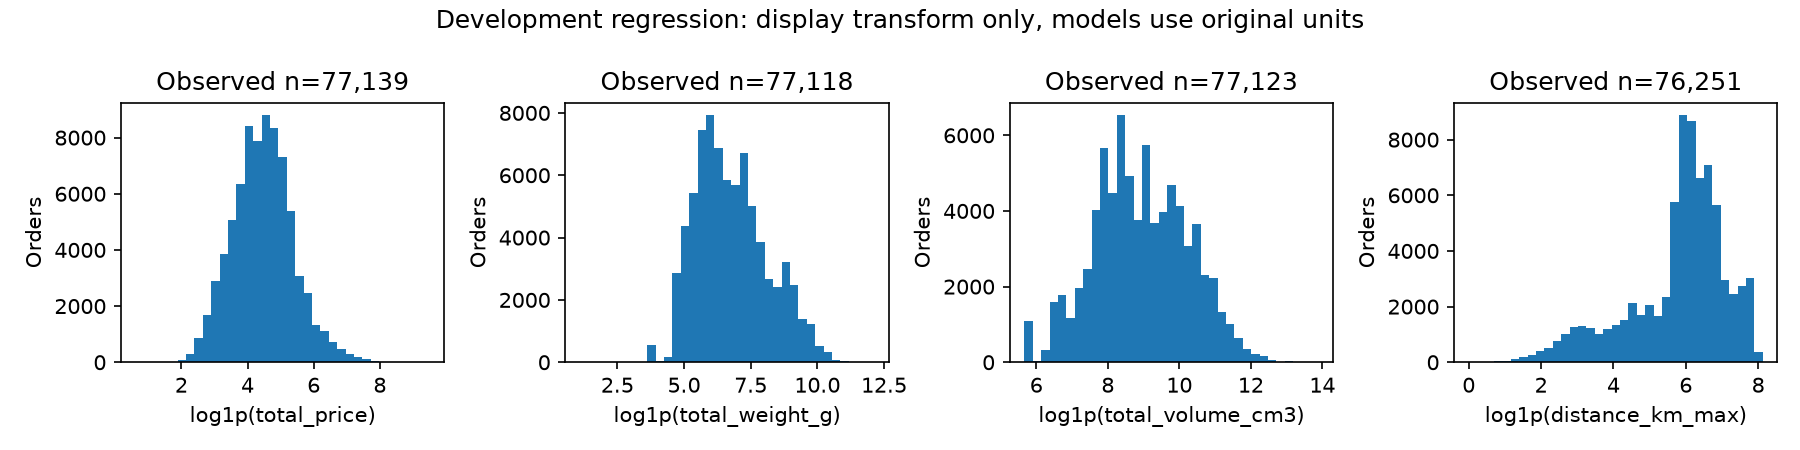

,feature,count,missing_n,missing_fraction,50%,max,constant_nonmissing
0,n_items,78938.0,0,0.000000,1.000000,2.000000e+01,False
1,has_items,78938.0,0,0.000000,1.000000,1.000000e+00,False
2,n_products,78938.0,0,0.000000,1.000000,7.000000e+00,False
3,n_sellers,78938.0,0,0.000000,1.000000,5.000000e+00,False
4,n_categories,78938.0,0,0.000000,1.000000,3.000000e+00,False
5,total_price,78334.0,604,0.007652,86.900000,1.344000e+04,False
6,total_freight,78334.0,604,0.007652,17.180000,7.113300e+02,False
7,freight_ratio,78334.0,604,0.007652,0.224374,2.144706e+01,False
8,freight_ratio_missing,78938.0,0,0.000000,0.000000,1.000000e+00,False
9,total_weight_g,78313.0,625,0.007918,750.000000,1.844000e+05,False


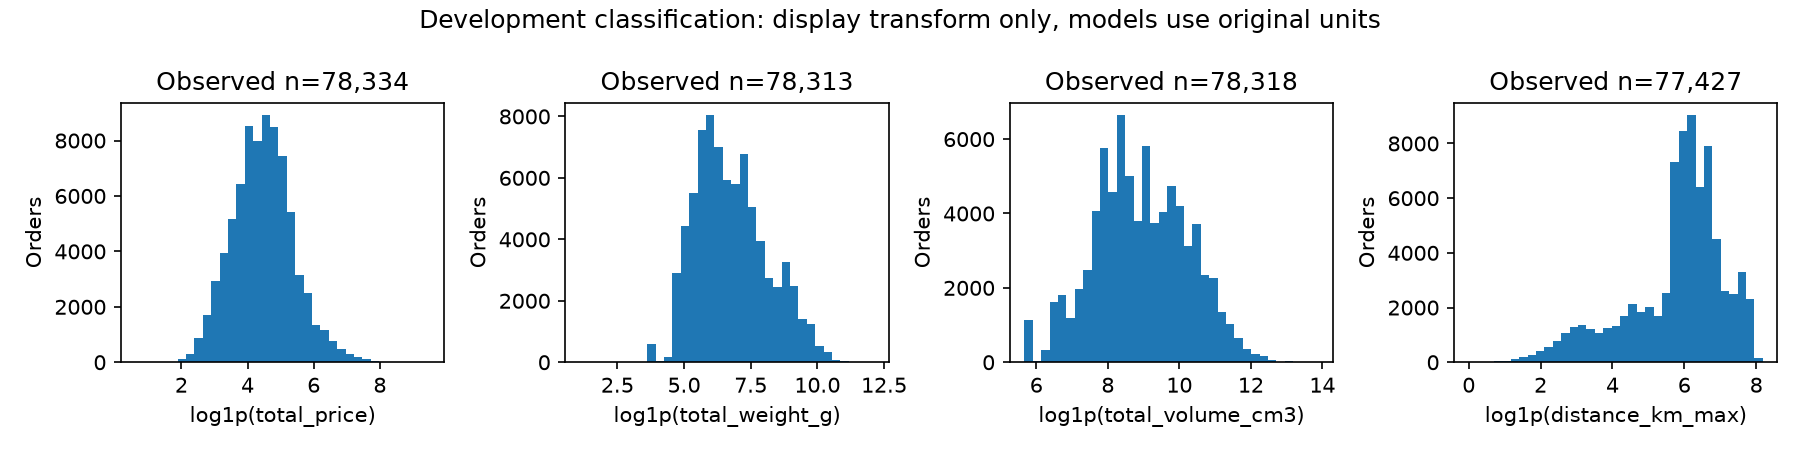

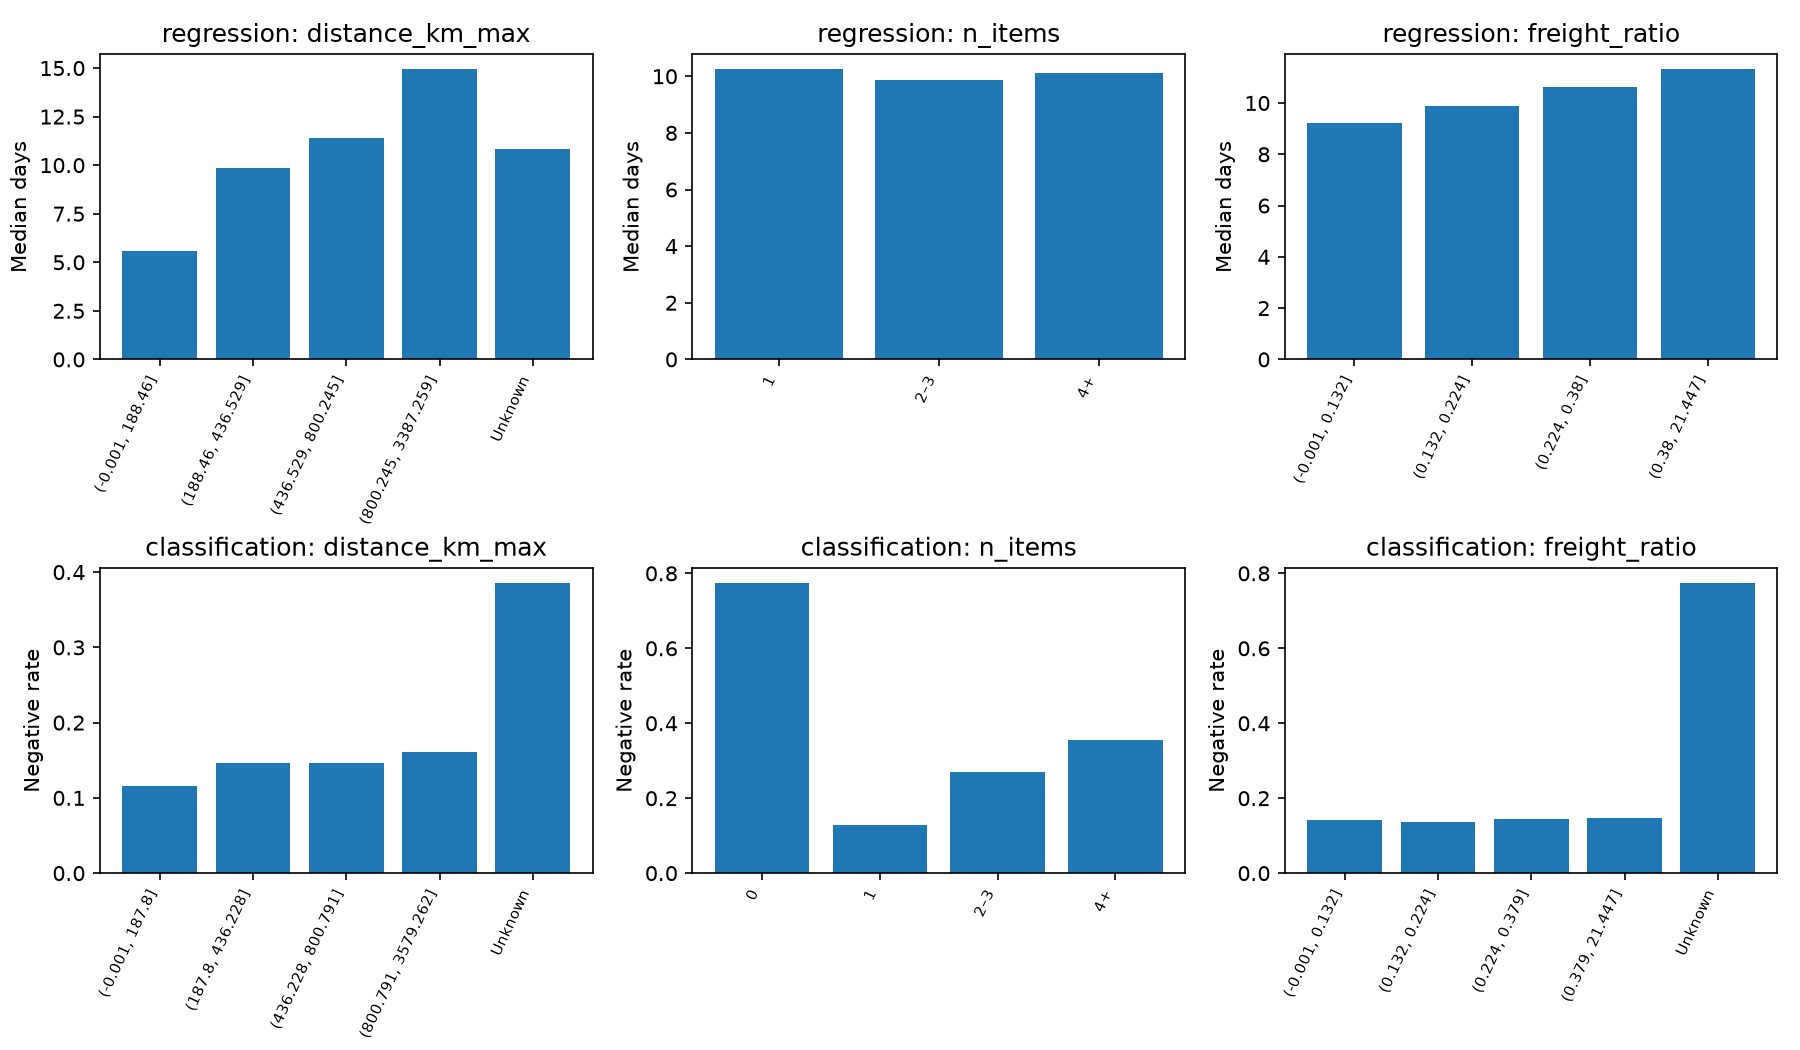

,eda_group,n,mean,median,p25,p75,feature,task,missing_feature_n,positives
27,"(-0.001, 188.46]",19063,7.072701,5.587373,3.501834,8.457934,distance_km_max,regression,888,NaN
28,"(188.46, 436.529]",19063,11.925853,9.877303,7.069155,14.068478,distance_km_max,regression,888,NaN
29,"(436.529, 800.245]",19062,13.632769,11.382309,8.102549,16.367578,distance_km_max,regression,888,NaN
30,"(800.245, 3387.259]",19063,17.478918,14.949931,10.738704,21.190324,distance_km_max,regression,888,NaN
31,Unknown,888,12.937267,10.854653,7.301794,16.075168,distance_km_max,regression,888,NaN
38,1,69365,12.614588,10.255521,6.815255,15.810625,n_items,regression,0,NaN
39,2–3,7005,11.766714,9.869063,6.281343,14.854873,n_items,regression,0,NaN
40,4+,769,12.079912,10.113472,6.867917,15.183275,n_items,regression,0,NaN
64,"(-0.001, 0.132]",19285,11.595305,9.233079,6.003299,14.322083,freight_ratio,regression,0,NaN
65,"(0.132, 0.224]",19360,12.008778,9.899676,6.373380,14.936534,freight_ratio,regression,0,NaN


In [3]:
audit = json.loads((OUT/'eda/audit_summary.json').read_text())
display(pd.DataFrame(audit['tasks']).T)
for task in ['regression','classification']:
    summary = pd.read_csv(OUT/f'eda/{task}_numeric_summary.csv')
    display(summary[['feature','count','missing_n','missing_fraction','50%','max','constant_nonmissing']])
    display(Image(filename=str(OUT/f'eda/figures/{task}_distributions.png')))
display(Image(filename=str(OUT/'eda/figures/relationships.png')))
relations = pd.read_csv(OUT/'eda/feature_outcome_relationships.csv')
display(relations[relations.feature.isin(['distance_km_max','n_items','freight_ratio'])])

## Outcome relationships and time trends
Use purchase-year-month, not just volume or pooled month-of-year. Denominators and quartiles are saved beside rates. Sparse/recent cohorts and variable review/delivery follow-up limit interpretation. Actual delivery versus review is outcome analysis and cannot enter the checkout classifier. Late uses actual timestamp greater than estimated timestamp at original precision, not date-only comparison. These associations do not identify logistics mechanisms or intervention effects.

,purchase_year_month,n,median,p25,p75,late_valid_n,late_rate
0,2016-09,1,54.813194,54.813194,54.813194,1,1.000000
1,2016-10,201,17.953958,8.930961,25.523900,201,0.004975
2,2016-12,1,4.693021,4.693021,4.693021,1,0.000000
3,2017-01,602,10.646921,7.705058,13.957332,602,0.033223
4,2017-02,1315,11.136458,7.723003,15.919936,1315,0.033460
5,2017-03,2014,10.098970,6.986282,14.616181,2014,0.055611
6,2017-04,1815,12.662766,8.687477,18.037529,1815,0.077135
7,2017-05,2828,9.777245,6.910758,13.836777,2828,0.037482
8,2017-06,2502,10.803455,7.300900,14.454696,2502,0.033573
9,2017-07,3112,10.164832,7.062240,14.335119,3112,0.035668


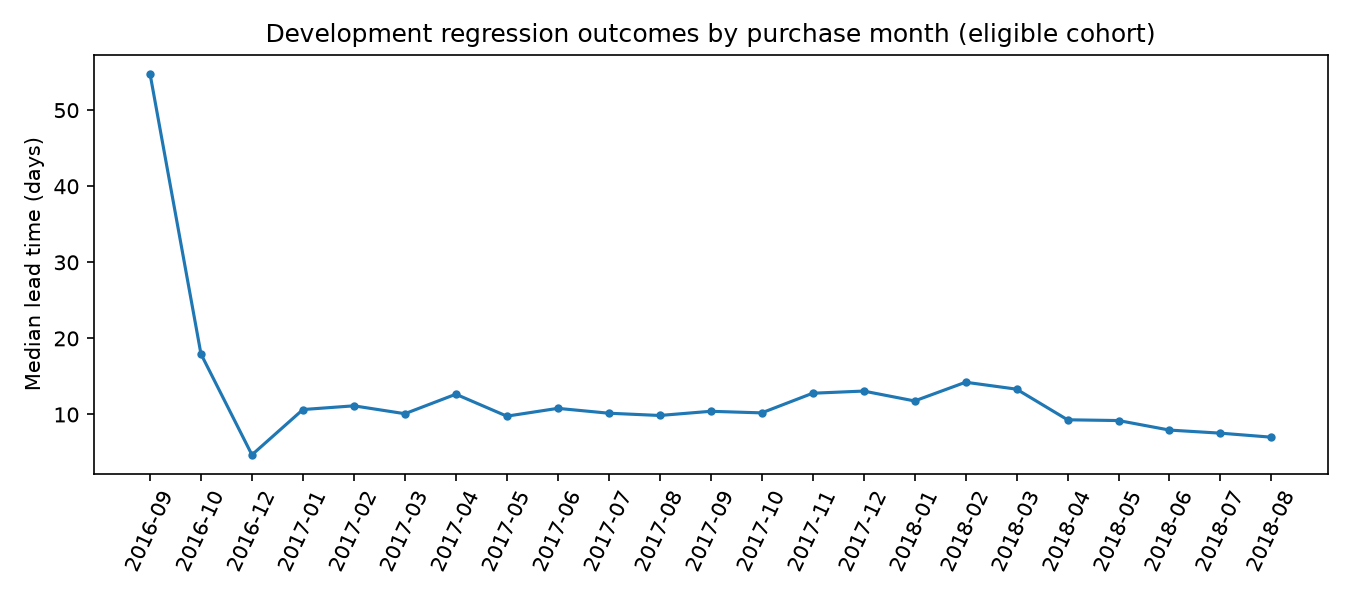

,purchase_year_month,n,positives,negative_rate
0,2016-09,4,4.0,1.000000
1,2016-10,244,65.0,0.266393
2,2016-12,1,0.0,0.000000
3,2017-01,633,99.0,0.156398
4,2017-02,1412,232.0,0.164306
5,2017-03,2098,290.0,0.138227
6,2017-04,1888,301.0,0.159428
7,2017-05,2924,386.0,0.132011
8,2017-06,2562,317.0,0.123731
9,2017-07,3206,391.0,0.121959


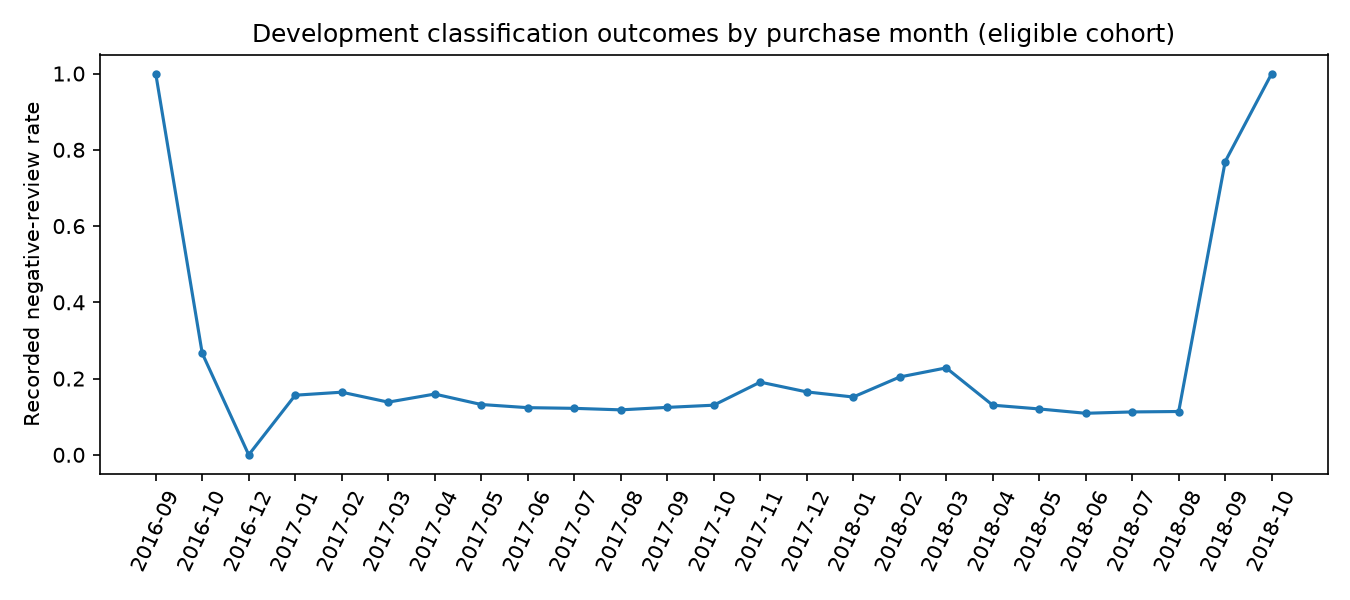

,duration_band,n,positives,negative_rate
0,0–7,20684,1531.0,0.074019
1,14–30,20353,3189.0,0.156685
2,7–14,32089,2902.0,0.090436
3,>30,3496,2202.0,0.629863


,late,n,positives,negative_rate
0,0.0,70528,6530.0,0.092587
1,1.0,6094,3294.0,0.540532


In [4]:
for task in ['regression','classification']:
    display(pd.read_csv(OUT/f'eda/{task}_monthly_outcomes.csv'))
    display(Image(filename=str(OUT/f'eda/figures/{task}_monthly.png')))
display(pd.read_csv(OUT/'eda/review_vs_duration_band_diagnostic.csv'))
display(pd.read_csv(OUT/'eda/review_vs_late_diagnostic.csv'))

## Review-policy sensitivity
The minimum policy means any recorded negative review, not first/final satisfaction. The alternative is the earliest valid answered review at/after purchase, with deterministic answer-time/review-ID/source-row ties. Invalid/missing/pre-purchase answer dates are excluded from the alternative, never imputed. Compare common orders to separate label changes from denominator changes. Baseline targets/folds remain unchanged; no alternate model was trained.

In [5]:
review = json.loads((OUT/'eda/review_label_audit.json').read_text())
display(pd.DataFrame(review['matched']).T)
display(review['exclusions_first_failure'])
if (OUT/'eda/review_label_comparison.csv').exists():
    comparison = pd.read_csv(OUT/'eda/review_label_comparison.csv')
    display(pd.crosstab(comparison.is_detractor, comparison.is_detractor_first).reindex(index=[0,1],columns=[0,1],fill_value=0))
    display(comparison[comparison.label_disagrees.eq(1)].head(3))
else:
    print('Detailed per-order label comparison is omitted from the compact checkpoint; summary is shown above.')

,baseline_prevalence,disagreements,first_prevalence,first_score_counts,minimum_score_counts,n,prevalence_difference
all,0.146925,47,0.146329,"{'1': 9045, '2': 2498, '3': 6495, '4': 15261, ...","{'1.0': 9084, '2.0': 2506, '3.0': 6512, '4.0':...",78884,0.000596
multi_review,0.25167,47,0.146993,"{'1': 50, '2': 16, '3': 41, '4': 77, '5': 265}","{'1.0': 89, '2.0': 24, '3.0': 58, '4.0': 77, '...",449,0.104677


{'answer_before_purchase': 57, 'usable': 79334}

is_detractor_first,0,1
is_detractor,,
0,67294,0
1,47,11543


,order_id,review_score_min,is_detractor,review_count,review_score_first,answer,review_id,source_row_index,is_detractor_first,label_disagrees
664,02355020fd0a40a0d56df9f6ff060413,1.0,1.0,2,3,2018-03-22 01:32:08,0c8e7347f1cdd2aede37371543e3d163,89888,0,1
1546,04f1827088d972a62224f5203a071500,1.0,1.0,2,5,2018-01-03 10:40:06,f543cfa959c3289703f144a32113bd78,45108,0,1
2267,073fa4be4665f397a289842b1053229c,1.0,1.0,2,5,2018-01-24 20:26:57,55d37f60f12bd5af8b2185dda9ef6dea,89755,0,1


## Modelling discipline and methods
Five saved customer-group folds are reused; all preprocessing fits only fold training. Numeric median plus indicators retains missing inputs; nominal/calendar strings use OHE. Linear/logistic models scale numbers and drop one category reference; trees use unscaled numbers and full category indicators. Unseen categories can encode all zero, including a reference collision in linear models.
Dummy median/prior are no-feature references. OLS estimates an additive days function by squared loss; logistic estimates additive log odds with no penalty (C=inf), weighting or resampling. CART depth 5/min leaf 100 tests simple thresholds/interactions, using squared_error/Gini. Thirty fixed fits, no search. MAE primary measures days; AP primary evaluates negative-review ranking. RMSE/R² and ROC/confusion/Brier supplement them. Threshold 0.5 and top-10% ranking are diagnostic, not selected operating policies.

In [6]:
display(json.loads((OUT/'configuration.json').read_text()))
folds = pd.read_csv(OUT/'fold_metrics.csv')
pooled = pd.read_csv(OUT/'pooled_oof_metrics.csv')
display(pd.read_csv(OUT/'cv_summary.csv'))
display(pooled)
display(pd.read_csv(OUT/'paired_fold_differences.csv'))
print('Fold SD is variability, not a confidence interval; OOF is development evidence, not final evaluation.')

{'classification_diagnostic_threshold': 0.5,
 'diagnostic_review_capacity': 0.1,
 'holdout_evaluation': False,
 'hypotheses': {'label_audit': 'The minimum-review policy may increase recorded negative prevalence relative to earliest valid answered review.',
  'linear': 'Checkout features may improve over an intercept-only reference through additive effects / additive log odds.',
  'tree': 'A depth-5 CART may capture thresholds and interactions missed by additive models; no improvement is assumed.'},
 'linear': {'tol': 1e-06},
 'logistic': {'C': 'infinity',
  'class_weight': None,
  'max_iter': 2000,
  'solver': 'lbfgs',
  'tol': 0.0001},
 'models': ['dummy', 'linear', 'tree'],
 'primary_metrics': {'classification': 'average_precision',
  'regression': 'mae'},
 'seed': 42,
 'selection': 'none; Stage 4 required',
 'subgroups': ['customer_state', 'basket_size'],
 'tasks': ['regression', 'classification'],
 'tree': {'ccp_alpha': 0.0,
  'max_depth': 5,
  'min_samples_leaf': 100,
  'min_sampl

,task,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,average_precision_mean,average_precision_std,...,brier_mean,brier_std,precision_1_mean,precision_1_std,recall_1_mean,recall_1_std,f1_1_mean,f1_1_std,accuracy_mean,accuracy_std
0,classification,dummy,NaN,NaN,NaN,NaN,NaN,NaN,0.147280,0.000021,...,0.125589,0.000015,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.852720,0.000021
1,classification,linear,NaN,NaN,NaN,NaN,NaN,NaN,0.297311,0.002469,...,0.117608,0.000128,0.664937,0.031452,0.063134,0.005422,0.115245,0.008954,0.857306,0.000721
2,classification,tree,NaN,NaN,NaN,NaN,NaN,NaN,0.260873,0.004256,...,0.118555,0.000323,0.644178,0.047237,0.060811,0.011188,0.110738,0.018440,0.856571,0.000721
3,regression,dummy,6.089709,0.072548,9.713962,0.303683,-0.060563,0.001753,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,regression,linear,4.992532,0.071198,7.961865,0.300429,0.287730,0.008798,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,regression,tree,5.219387,0.053004,8.265113,0.295964,0.232373,0.006783,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,task,model,partition,n,mae,rmse,r2,negative_predictions,positives,negatives,...,fpr,fnr,specificity,precision_defined,ranking_metrics_defined,capacity_fraction,selected_n,captured_positives,precision_at_capacity,recall_at_capacity
0,regression,dummy,development_oof,77139,6.089709,9.717760,-0.060479,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,regression,linear,development_oof,77139,4.992533,7.966399,0.287321,8.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,regression,tree,development_oof,77139,5.219388,8.269353,0.232086,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,classification,dummy,development_oof,78938,NaN,NaN,NaN,NaN,11626.0,67312.0,...,0.000000,1.000000,1.000000,False,True,0.1,7894.0,1174.0,0.148721,0.100981
4,classification,linear,development_oof,78938,NaN,NaN,NaN,NaN,11626.0,67312.0,...,0.005527,0.936866,0.994473,True,True,0.1,7894.0,2841.0,0.359894,0.244366
5,classification,tree,development_oof,78938,NaN,NaN,NaN,NaN,11626.0,67312.0,...,0.005987,0.939188,0.994013,True,True,0.1,7894.0,2751.0,0.348493,0.236625


,task,metric,candidate,reference,fold,candidate_minus_reference,improvement
0,regression,mae,linear,dummy,0,-1.101759,1.101759
1,regression,mae,linear,dummy,1,-1.052079,1.052079
2,regression,mae,linear,dummy,2,-1.090159,1.090159
3,regression,mae,linear,dummy,3,-1.096030,1.096030
4,regression,mae,linear,dummy,4,-1.145858,1.145858
5,regression,mae,tree,dummy,0,-0.890186,0.890186
6,regression,mae,tree,dummy,1,-0.813937,0.813937
7,regression,mae,tree,dummy,2,-0.873374,0.873374
8,regression,mae,tree,dummy,3,-0.882746,0.882746
9,regression,mae,tree,dummy,4,-0.891367,0.891367


Fold SD is variability, not a confidence interval; OOF is development evidence, not final evaluation.


## Diagnostics and limitations
Residuals are observed minus predicted days; heavy tails and changing spread challenge simple models, not automatically invalidate long deliveries. Check linear rank/conditioning before interpreting coefficients. Scaling does not remove collinearity; coefficient position is not a stable feature identity across folds. Reliability bins compare observed rate with predicted probability and have saved support counts; no calibrator is fitted. Tree figures show only top levels, not the entire fitted tree. Training scores are resubstitution diagnostics. State/basket subgroups report support, not demographic fairness.

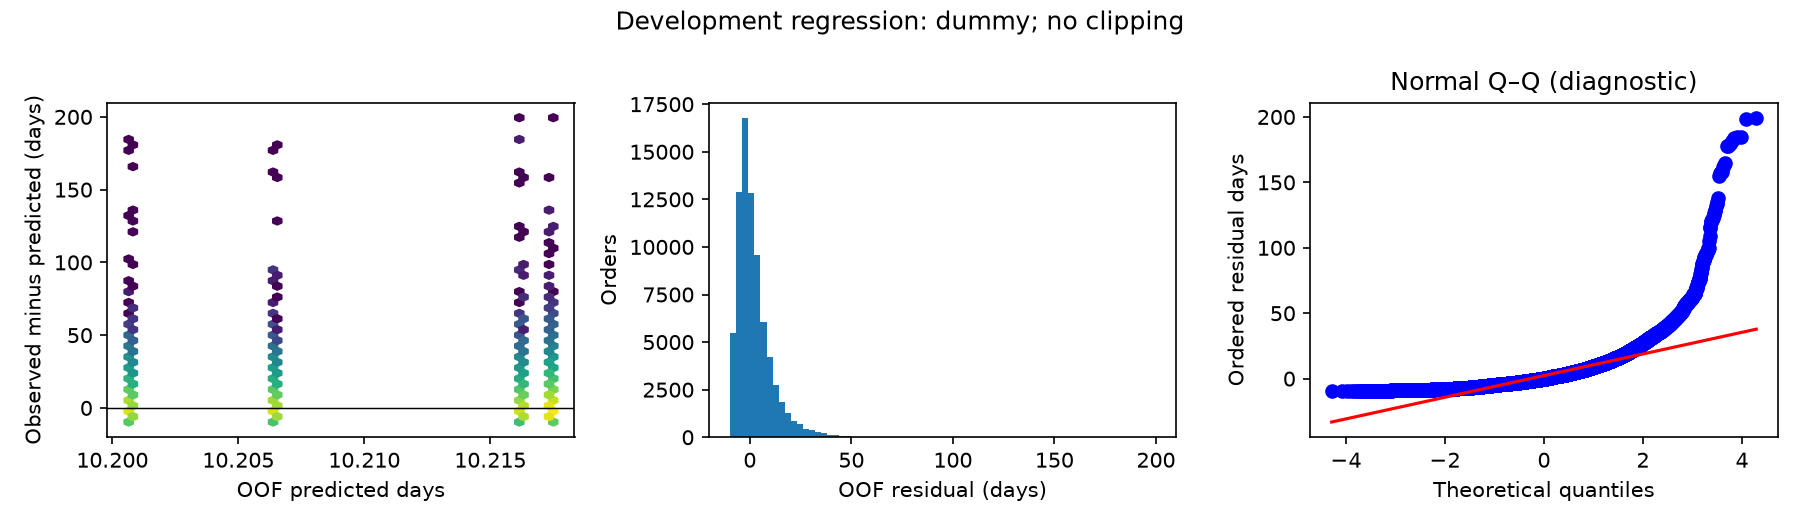

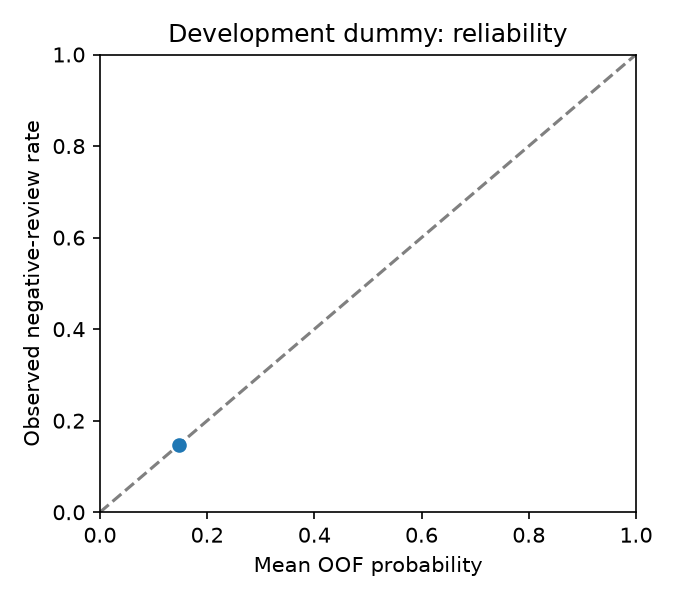

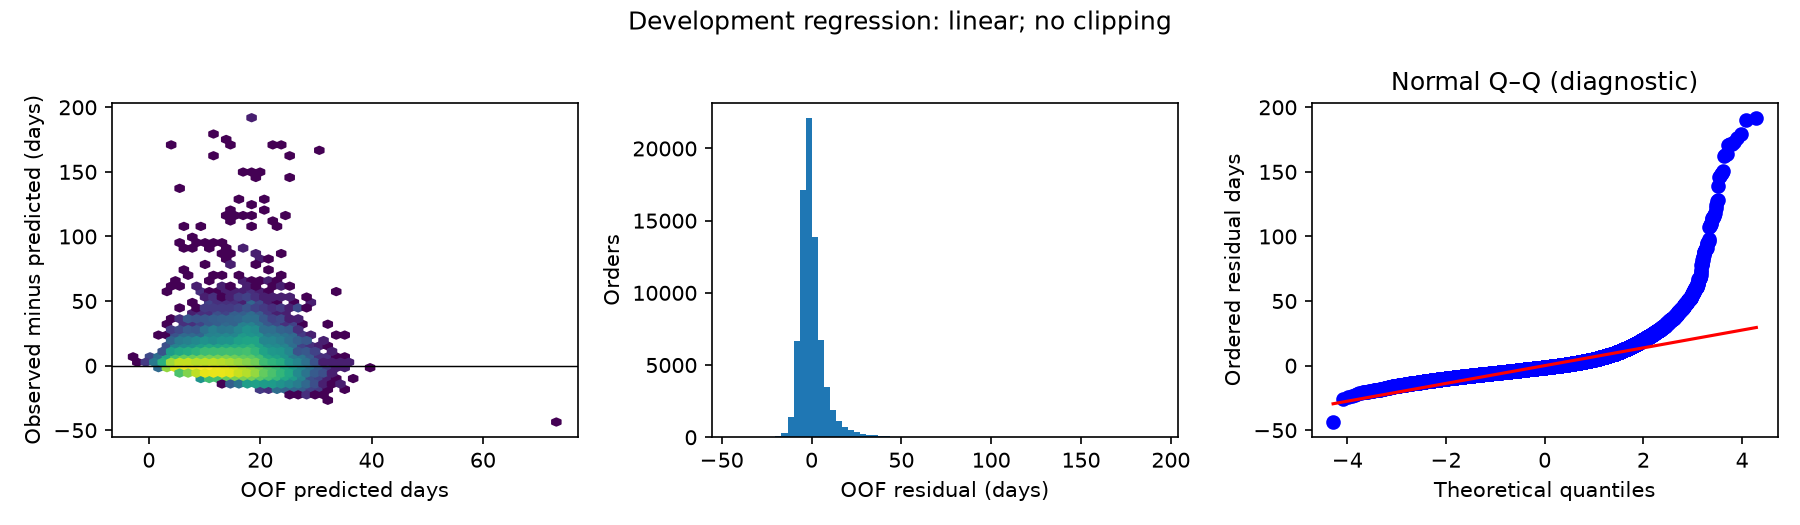

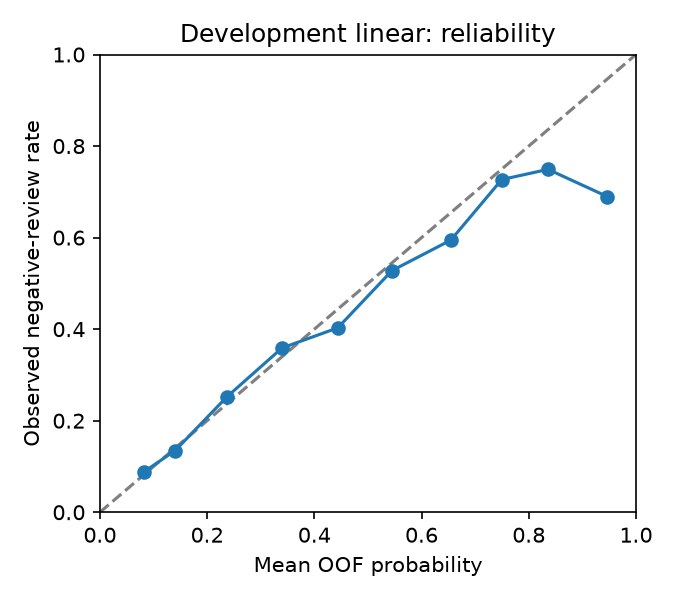

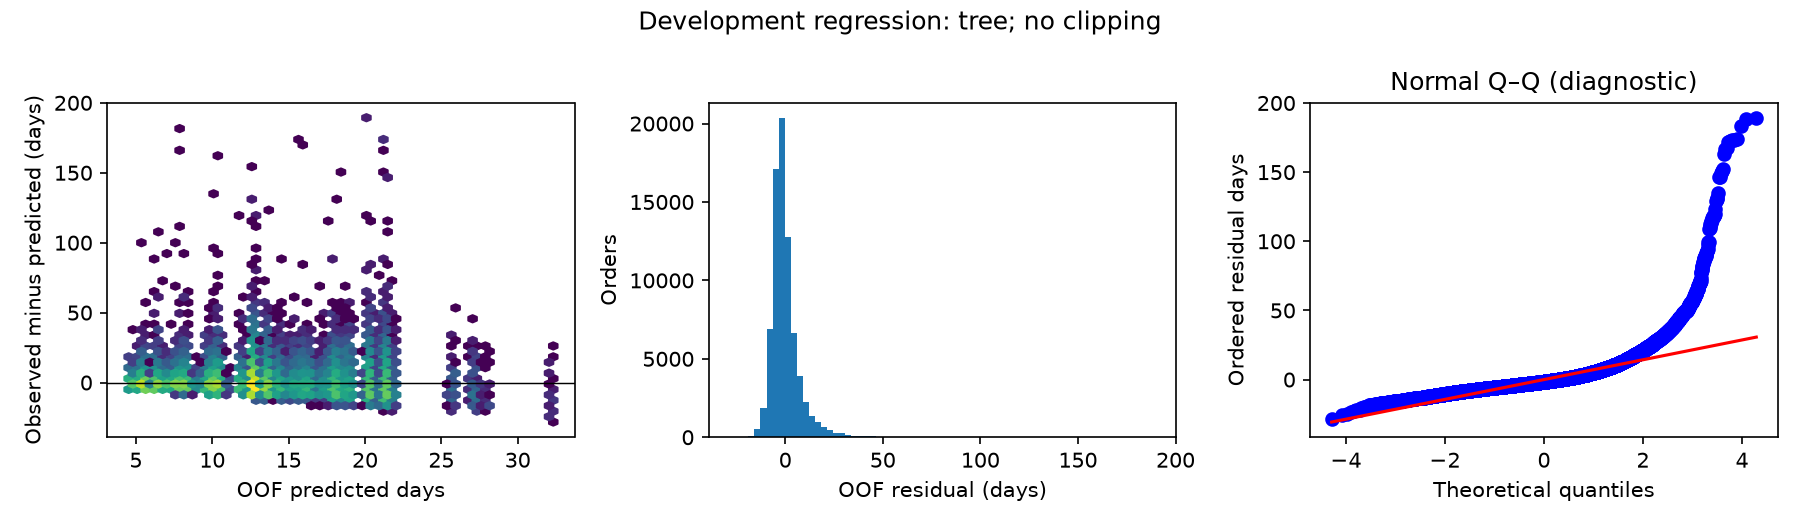

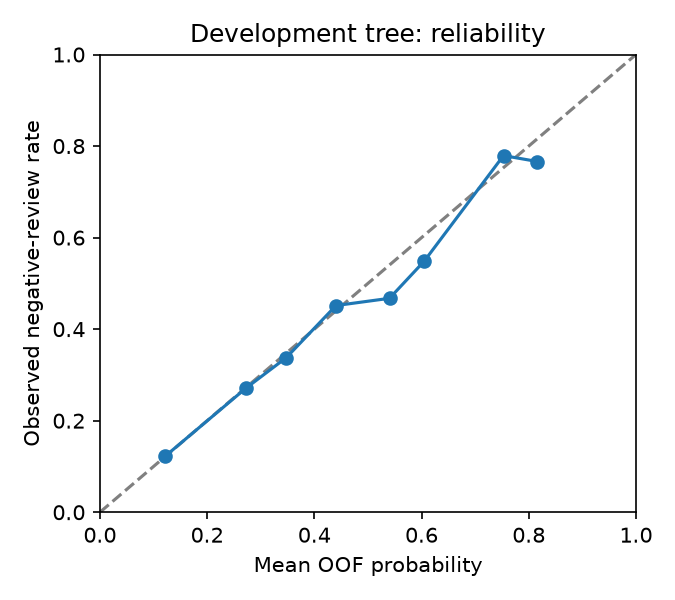

{'columns_with_intercept': 187,
 'condition_number': None,
 'constant_columns': [0, 2, 9, 20, 24, 60, 63, 67, 70, 95, 118, 124, 127, 133],
 'dense_bytes': 7480000,
 'limitation': 'sample rank/conditioning only; no OLS inference or full-matrix rank claim',
 'nonzero_subspace_condition_number': 1424.0468471959891,
 'numerical_rank': 170,
 'rank_deficient': True,
 'rank_tolerance': 1.582057962728412e-10,
 'sample_policy': 'up to 5000 evenly spaced sorted training orders',
 'sample_training_n': 5000}

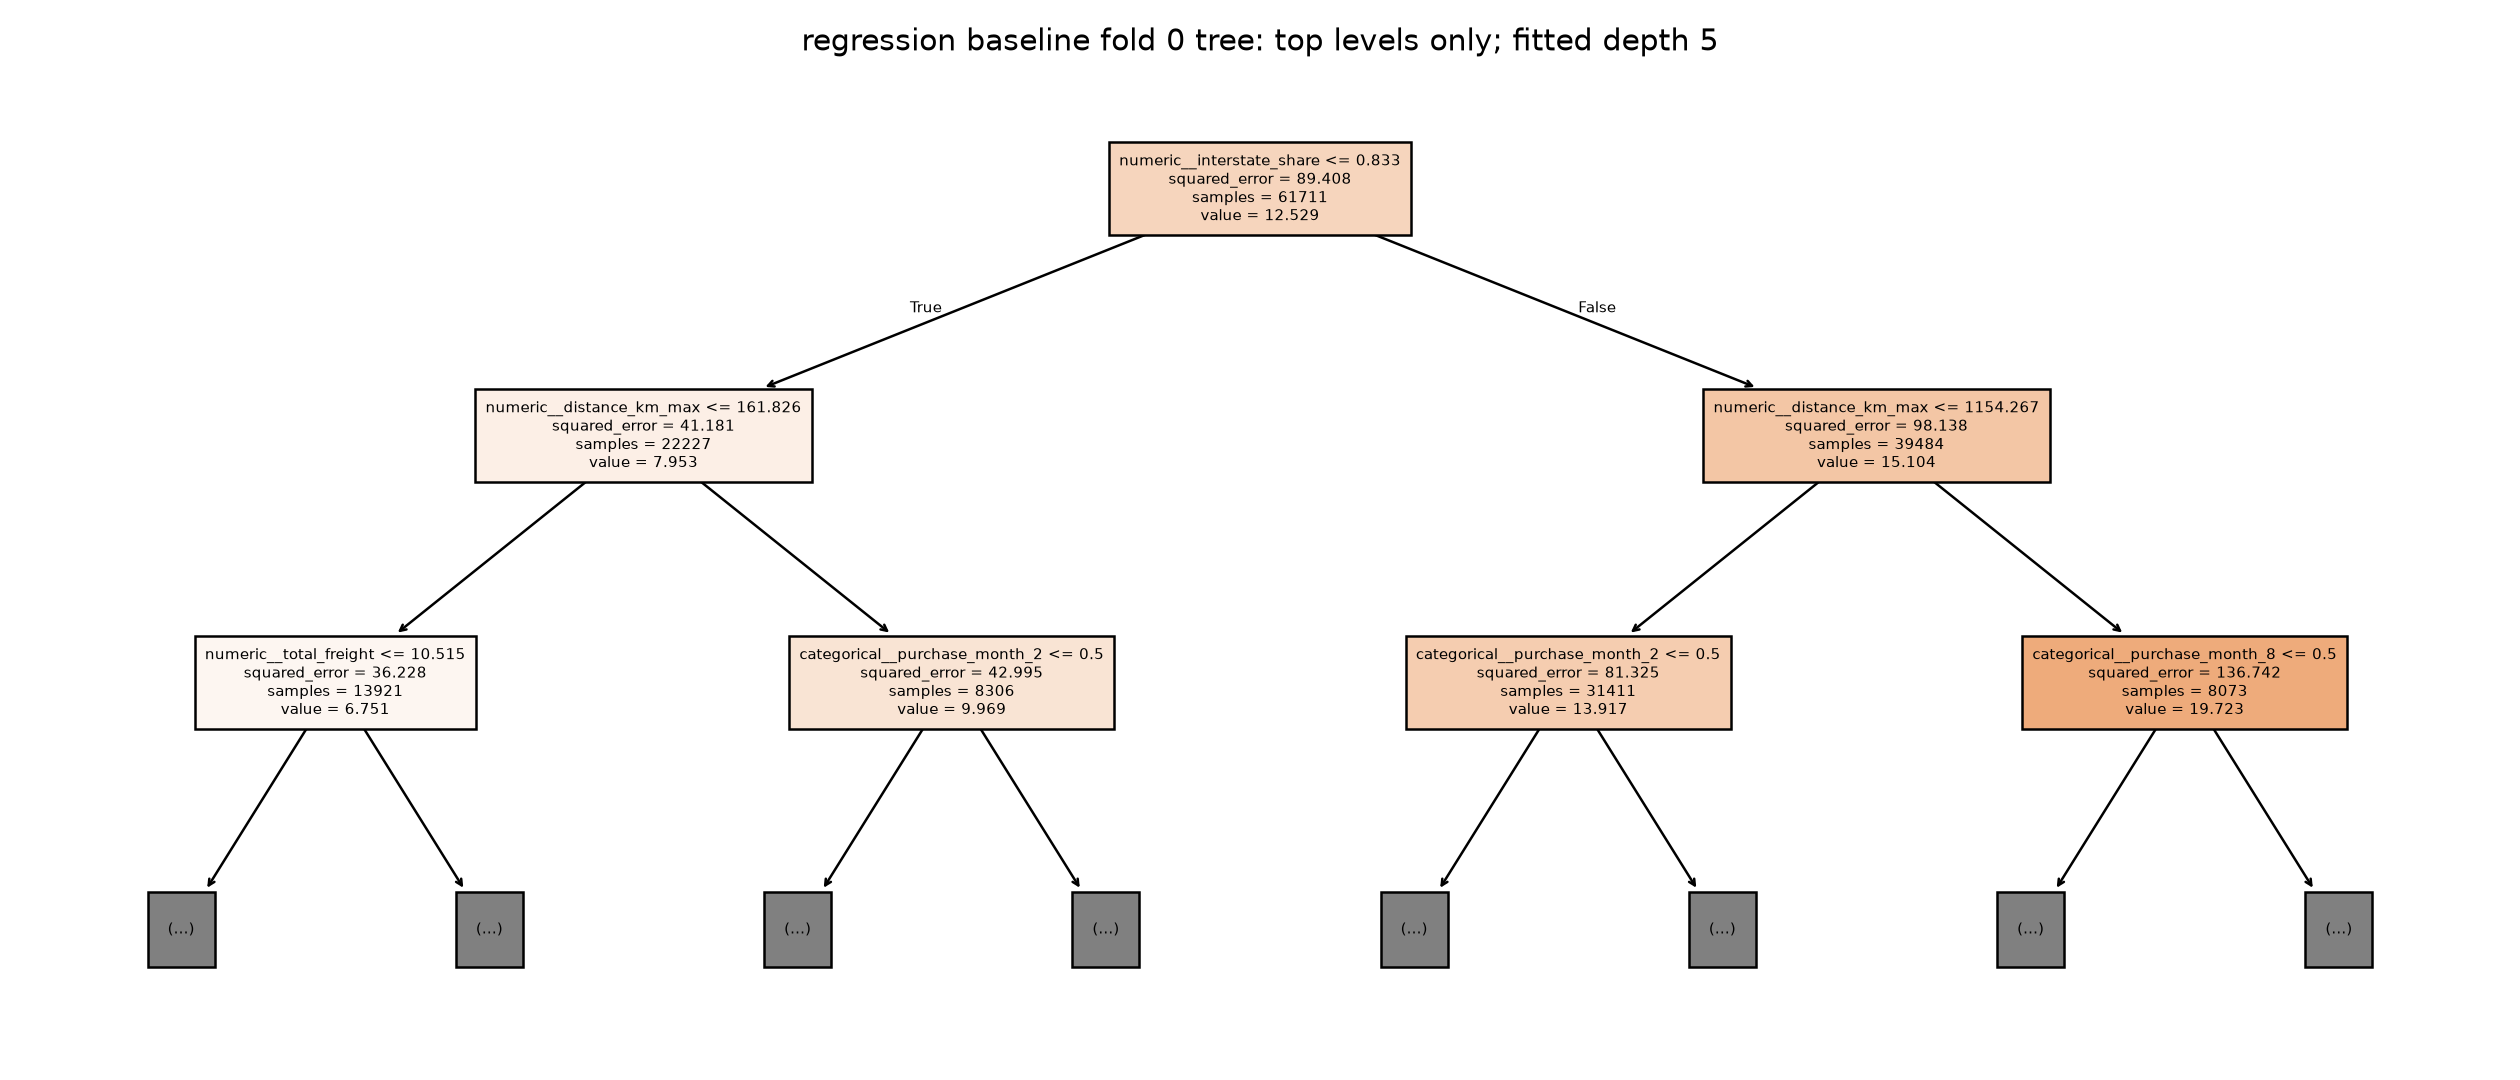

,task,model,feature,group,n,mae,rmse,r2,negative_predictions
0,regression,dummy,customer_state,AC,72,10.297678,13.763273,-1.220876,0
1,regression,dummy,customer_state,AL,327,14.448463,18.322932,-1.522721,0
2,regression,dummy,customer_state,AM,114,16.621256,21.996038,-1.139551,0
3,regression,dummy,customer_state,AP,57,15.180076,17.115371,-3.195244,0
4,regression,dummy,customer_state,BA,2560,9.818695,14.986802,-0.610569,0


{'columns_with_intercept': 196,
 'condition_number': None,
 'constant_columns': [0, 68, 78, 84, 92, 104, 110, 133, 142],
 'dense_bytes': 7840000,
 'limitation': 'sample rank/conditioning only; no OLS inference or full-matrix rank claim',
 'nonzero_subspace_condition_number': 3068.2904331514706,
 'numerical_rank': 172,
 'rank_deficient': True,
 'rank_tolerance': 2.927336038244271e-10,
 'sample_policy': 'up to 5000 evenly spaced sorted training orders',
 'sample_training_n': 5000}

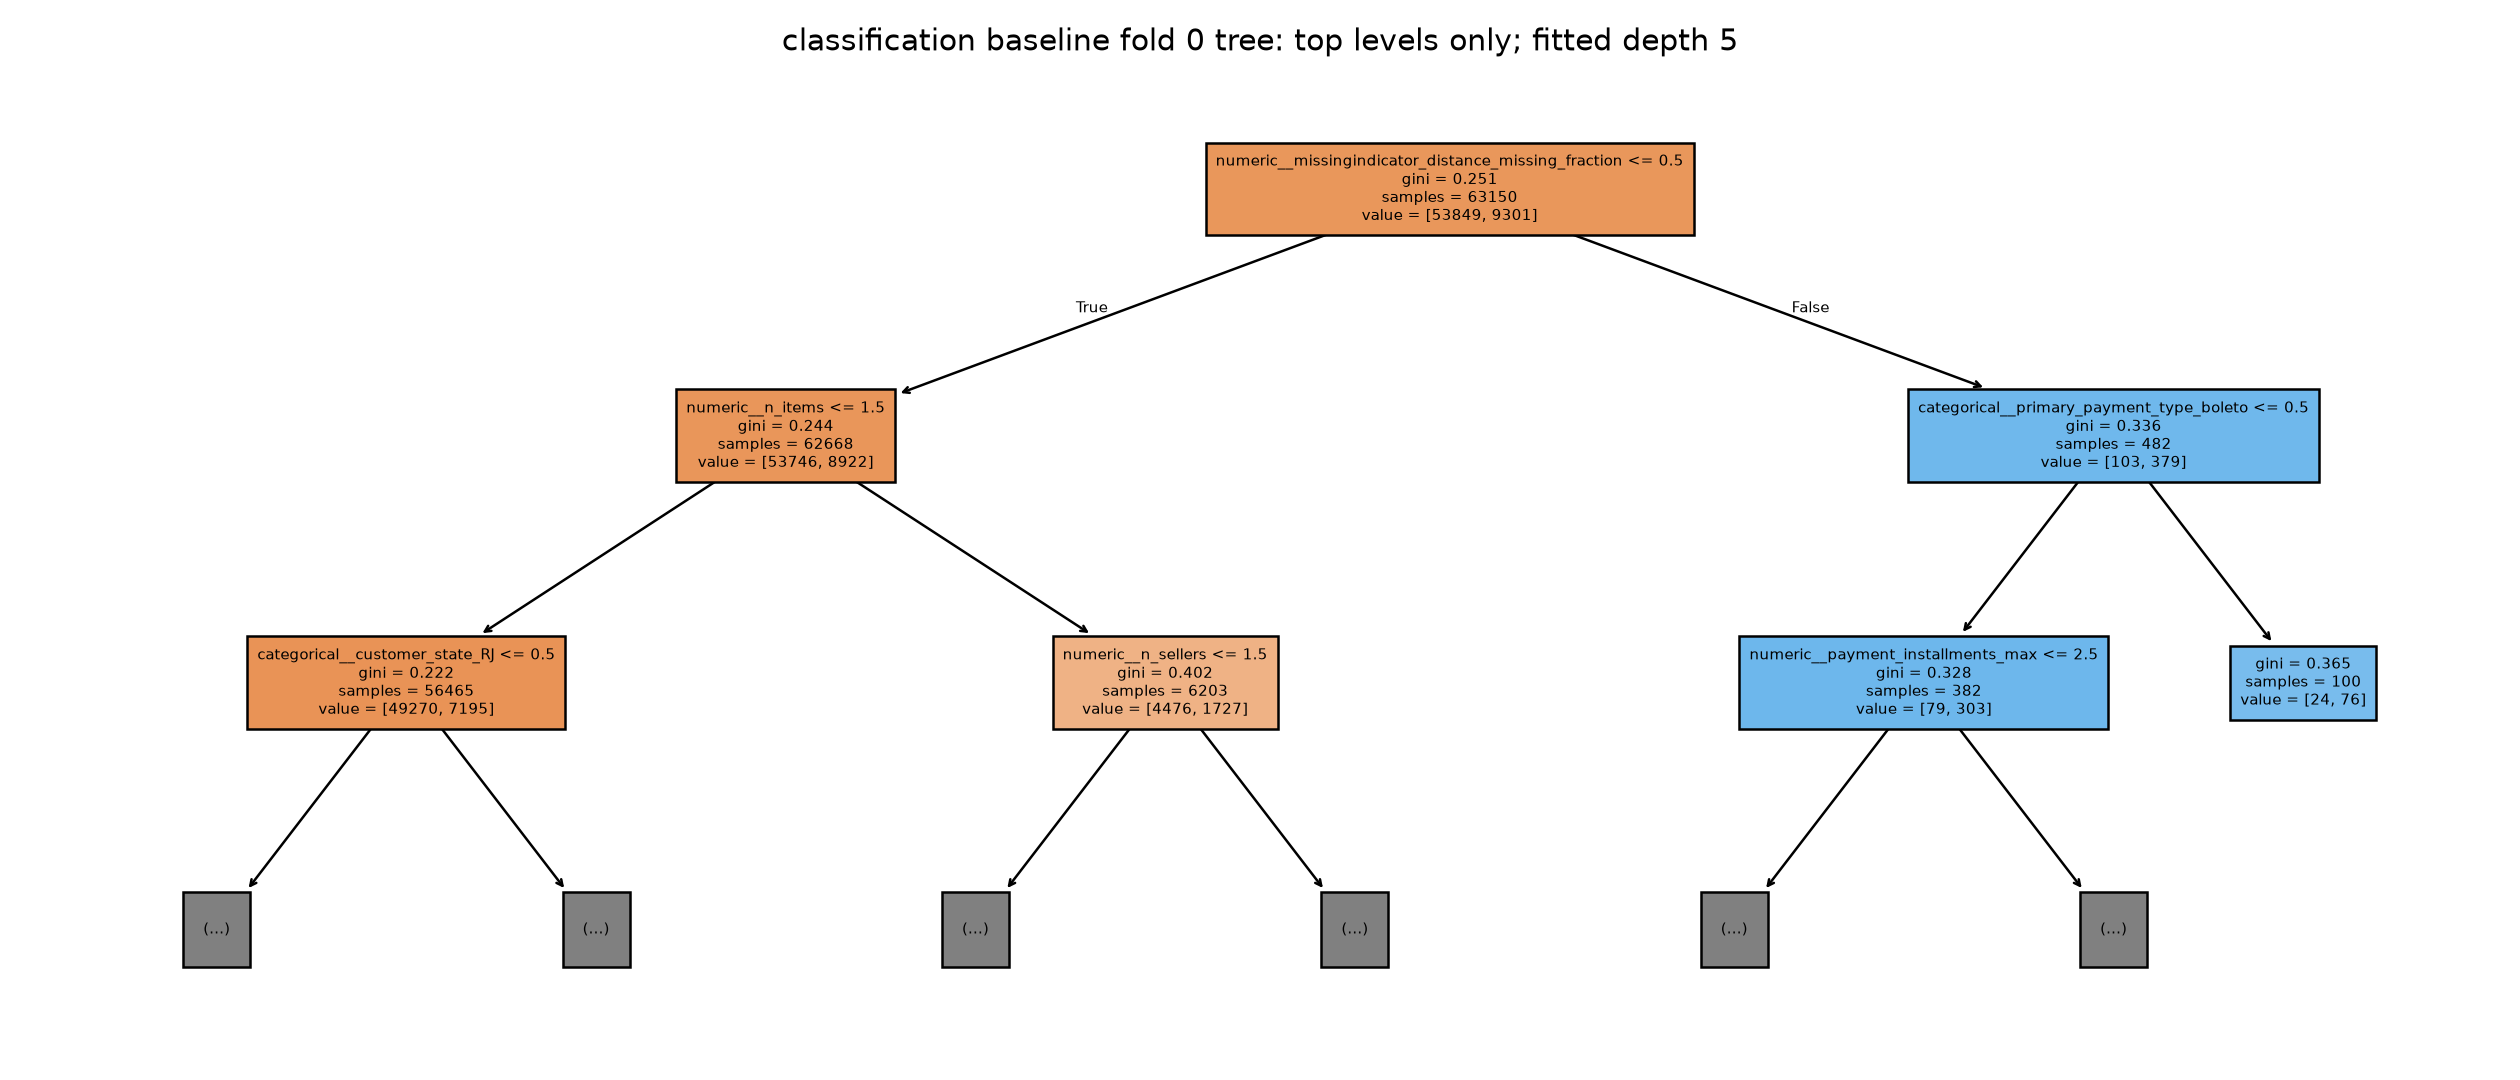

,task,model,feature,group,n,positives,negatives,prevalence,threshold,average_precision,...,f1_1,tn,fp,fn,tp,fpr,fnr,specificity,precision_defined,ranking_metrics_defined
0,classification,dummy,customer_state,AC,73,11,62,0.150685,0.5,0.211639,...,0.0,62,0,11,0,0.0,1.0,1.0,False,True
1,classification,dummy,customer_state,AL,336,81,255,0.241071,0.5,0.245117,...,0.0,255,0,81,0,0.0,1.0,1.0,False,True
2,classification,dummy,customer_state,AM,115,17,98,0.147826,0.5,0.184413,...,0.0,98,0,17,0,0.0,1.0,1.0,False,True
3,classification,dummy,customer_state,AP,57,4,53,0.070175,0.5,0.110771,...,0.0,53,0,4,0,0.0,1.0,1.0,False,True
4,classification,dummy,customer_state,BA,2635,498,2137,0.188994,0.5,0.188208,...,0.0,2137,0,498,0,0.0,1.0,1.0,False,True


,task,model,fold,partition,mae,average_precision,fit_seconds
0,regression,dummy,0,training_resubstitution,6.076098,NaN,0.462811
1,regression,dummy,0,validation,6.143993,NaN,0.462811
2,regression,dummy,1,training_resubstitution,6.116613,NaN,0.404788
3,regression,dummy,1,validation,5.981934,NaN,0.404788
4,regression,dummy,2,training_resubstitution,6.077612,NaN,0.396186
5,regression,dummy,2,validation,6.137932,NaN,0.396186
6,regression,dummy,3,training_resubstitution,6.077630,NaN,0.417807
7,regression,dummy,3,validation,6.137902,NaN,0.417807
8,regression,dummy,4,training_resubstitution,6.100400,NaN,0.401017
9,regression,dummy,4,validation,6.046784,NaN,0.401017


In [7]:
for model in ['dummy','linear','tree']:
    display(Image(filename=str(OUT/f'diagnostics/regression_{model}_residuals.png')))
    display(Image(filename=str(OUT/f'diagnostics/classification_{model}_reliability.png')))
for task in ['regression','classification']:
    display(json.loads((OUT/f'diagnostics/{task}_linear_conditioning.json').read_text()))
    display(Image(filename=str(OUT/f'diagnostics/{task}_tree_top_levels.png')))
    display(pd.read_csv(OUT/f'diagnostics/{task}_subgroup_metrics.csv').head())
display(folds[['task','model','fold','partition','mae','average_precision','fit_seconds']])

## Measured findings and review before Stage 4

Development fold-mean MAE is 6.090 days for dummy, 4.993 for linear and 5.219 for the starting tree. Fold-mean AP is 0.1473 for prior, 0.2973 for logistic and 0.2609 for the starting tree. Linear/logistic improve on dummy and these trees in every fold; forests/tuning are not yet tested, so this is not final selection. Pooled AP differs from fold-mean AP: do not mix them.

Logistic recall at the diagnostic 0.5 threshold is only 0.0631, despite precision 0.6637. Ranking and operational decisions must be justified separately. Eight linear OOF duration predictions are negative and retained unclipped; sampled rank deficiency and residual tails limit coefficient inference.

The review policy audit changes 47 of 78,884 common labels: a small overall prevalence difference (0.0596 percentage points) but a larger multi-review difference (10.4677 points, N=449). Itemless/incomplete-distance orders have elevated recorded-negative rates; their actual checkout availability is unproven. Preserve the baseline and test a named development-only availability sensitivity in Stage 4. These are associations, not causal mechanisms.
Read the saved handoff interpretation; independent verification and human explanation review are still pending. Explain the join example, minimum/first label disagreement, absolute/squared error, and false-alert/missed-review trade-off in your own words. Record teammate opinions without overwriting baseline evidence.
Next stage only after review: bounded tuning and forest comparison, development-based selection and operational policy. Final holdout and deployment-ready bundles belong to Stage 5; the submission report belongs to Stage 6. Do not fit histories, cascades, calibration or additional families silently.